## 2 excitatory neurons

#### Scheme:

    2 coupled neurons, E1 and E2
    Different inputs (static currents or sinusoids)
    E1 has an autapse of varying strength

#### Question:

    Can E1 entrain E2? 
    Does the autapse help?
    
#### Parameters to vary:

    Respective inputs I1/I2, which neuron fires more?
    synapse strengths: Which neuron holds more influence?
    autapse strength: Can the behaviour change as the autapse is strengthened?

#### Metrics:

    -> compare to uncoupled system
    -> van Rossum distance? do the neurons synchronise better?
    -> Which neuron entrains which? Is there a way to show which neuron adapts more? 


In [1]:
''' import aqua'''
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')

In [3]:
# non-autaptic neuron
E2 = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

# strong autaptic neuron
E1 = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 2.}

RS_mid = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150., 'tau': 2.}

In [4]:
start_scope()

# simulation parameters
T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

# neuron parameters
params = [E1, E2]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch = batchAQUA(params)
batch.Initialise(x_start, t_start)

# create the input current
I_h1 = 75
I1 = I_h1 * np.ones(N_iter)                 # E1 current
I_h2, _ = batch.get_threshold(idx = 1)      # E2 will be at threshold
I2 = I_h2 * np.ones(N_iter)                 # E2 current

I_inj = np.array([I1, I2])
I_TA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_inj')

# convert to brian2 with the standard autapse model
G, aut = batch.meetBrian(stimulus_name = I_TA)
# some synapse variables
G.I_syn = 0.
G.t_syn = 5.
# create the synapses between E1 and E2...
# describes how the synapse strength (w_syn) evolves over time
syn_eq = """
w_syn : 1
"""
# g_total_post = I_syn : 1 
syn_on_pre = '''I_syn += w_syn'''
syn = Synapses(G, G, 
                model = syn_eq,
                on_pre = syn_on_pre)

syn.connect(j = 'i != j')

## Set synapse strength
syn.w_syn[0, 1] = 200   #pA, weight from E1 -> E2
syn.w_syn[1, 0] = 200   #pA, weight from E2 -> E1

# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v = StateMonitor(G, 'v', record = True)
spikemon = SpikeMonitor(G, record = True)
M_syn = StateMonitor(syn, 'I_syn', record = True)

# create networks
net = Network(G, aut, syn, M_v, spikemon, M_syn)

net.run(T*ms)

spike_trains = spikemon.spike_trains()

- - threshold - -


100%|██████████| 59999/59999 [00:10<00:00, 5600.05it/s]


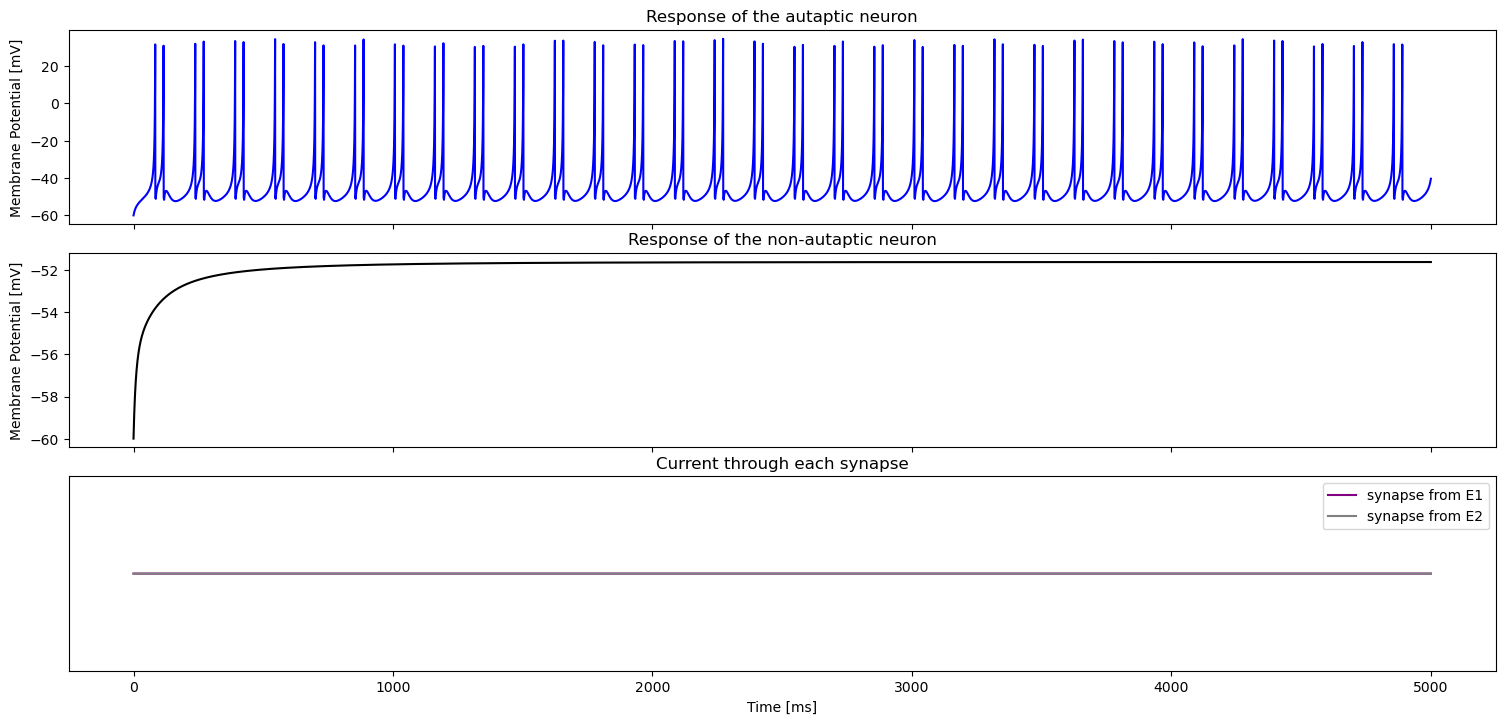

In [5]:
fig, ax = plt.subplots(3, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

ax[0].plot(M_v.t/ms, M_v.v[0], c = 'blue', label = 'autaptic neuron')
ax[0].set_title('Response of the autaptic neuron')
ax[0].set_ylabel('Membrane Potential [mV]')

ax[1].plot(M_v.t/ms, M_v.v[1], c = 'black', label = 'non-autaptic neuron')
ax[1].set_title('Response of the non-autaptic neuron')
ax[1].set_ylabel('Membrane Potential [mV]')


ax[2].plot(M_syn.t/ms, M_syn.I_syn[0], c = 'purple', label = 'synapse from E1')
ax[2].plot(M_syn.t/ms, M_syn.I_syn[1], c = 'gray', label = 'synapse from E2')
ax[2].set_yticks([])
ax[2].set_title('Current through each synapse')
ax[2].set_xlabel('Time [ms]')

plt.legend()

[0.0836 0.1158 0.2379 0.2705 0.3917 0.4242 0.5456 0.578  0.6997 0.7322
 0.8539 0.8866 1.0074 1.04   1.1616 1.1943 1.3155 1.3482 1.4697 1.5024
 1.6238 1.6563 1.7775 1.81   1.9317 1.9643 2.0859 2.1184 2.2397 2.2722
 2.3932 2.4257 2.5472 2.5799 2.7013 2.734  2.855  2.8877 3.0092 3.0416
 3.1636 3.1962 3.3179 3.3503 3.472  3.5046 3.6263 3.6588 3.7799 3.8124
 3.9338 3.9663 4.0879 4.1204 4.2422 4.2749 4.3957 4.4282 4.5494 4.5821
 4.7034 4.7361 4.8572 4.8898]


(array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 32.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0., 31.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([0.   , 0.003, 0.006, 0.009, 0.012, 0.015, 0.018, 0.021, 0.024,
        0.027, 0.03 , 0.033, 0.036, 0.039, 0.042, 0.045, 0.048, 0.051,
        0.054, 0.057, 0.06 , 0.063, 0.066, 0.069, 0.072, 0.075, 0.078,
        0.081, 0.084, 0.087, 0.09 , 0.093, 0.096, 0.099, 0.102, 0.105,
        0.108, 0.111, 0.114, 0.117, 0.12 , 0.123, 0.126, 0.129, 0.132,
        0.135, 0.138, 0.141, 0.144, 0.147, 0.15 ]),
 <a list of 2 lis

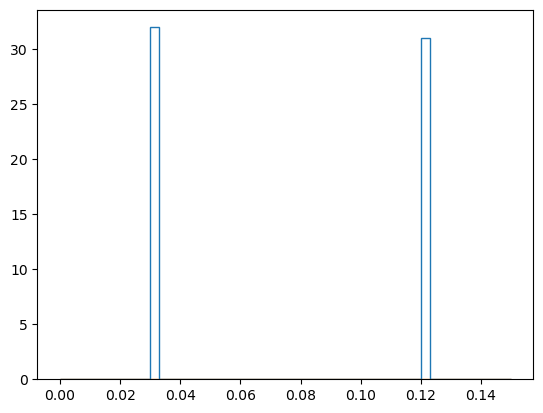

In [6]:
print(np.array(spike_trains[0]))
ST_0 = np.array(spike_trains[0])
ST_1 = np.array(spike_trains[1])

ISI_0 = np.ediff1d(ST_0)
ISI_1 = np.ediff1d(ST_1)

x = [ISI_0, ISI_1]

bins = 50
range = (0, 0.15)
plt.hist(x, bins = bins, range = range, histtype = 'step')
